In [1]:
%pip install tensorflow
%pip install opencv-python-headless
%pip install numpy


import tensorflow as tf
import cv2
import numpy as np
import os
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.models import Model

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
bengali_char_map = {
    0: "অ", 1: "আ", 2: "ই", 3: "ঈ", 4: "উ", 5: "ঊ", 6: "ঋ", 7: "এ", 8: "ঐ", 9: "ও", 10: "ঔ",
    11: "ক", 12: "খ", 13: "গ", 14: "ঘ", 15: "ঙ", 16: "চ", 17: "ছ", 18: "জ", 19: "ঝ", 20: "ঞ",
    21: "ট", 22: "ঠ", 23: "ড", 24: "ঢ", 25: "ণ", 26: "ত", 27: "থ", 28: "দ", 29: "ধ", 30: "ন",
    31: "প", 32: "ফ", 33: "ব", 34: "ভ", 35: "ম", 36: "য", 37: "র", 38: "ল", 39: "শ", 40: "ষ",
    41: "স", 42: "হ", 43: "ড়", 44: "ঢ়", 45: "য়", 46: "ৎ", 47: "ং", 48: "ঃ", 49: "ঁ"
}


In [4]:
def load_and_preprocess_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f"Warning: Unable to read image at {image_path}")
        return None
    image = cv2.resize(image, (32, 32))  # Resize to a fixed size
    image = image / 255.0  # Normalize pixel values
    image = np.expand_dims(image, axis=-1)  # Add channel dimension
    return image


In [5]:

def load_dataset(dataset_path):
    images = []
    labels = []
    class_names = sorted(os.listdir(dataset_path))
    valid_extensions = ('.bmp', '.png', '.jpg', '.jpeg')  # Add other valid extensions if needed
    for label, class_name in enumerate(class_names):
        class_path = os.path.join(dataset_path, class_name)
        for image_name in os.listdir(class_path):
            if image_name.lower().endswith(valid_extensions):
                image_path = os.path.join(class_path, image_name)
                image = load_and_preprocess_image(image_path)
                if image is not None:
                    images.append(image)
                    labels.append(label)
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32), class_names


In [6]:

# Dataset paths
train_dataset_path = 'CMATERdb 3.1.2/BasicFinalDatabase/Train'
test_dataset_path = 'CMATERdb 3.1.2/BasicFinalDatabase/Test'

train_images, train_labels, train_class_names = load_dataset(train_dataset_path)
test_images, test_labels, test_class_names = load_dataset(test_dataset_path)


In [7]:

def build_ann_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Flatten()(inputs)
    x = Dense(512, activation='relu')(x)
    x = Dense(256, activation='relu')(x)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model


In [8]:

# Build Model
input_shape = (32, 32, 1)  # Height, Width, Channels
num_classes = len(train_class_names)  # Number of unique Bengali letters

model = build_ann_model(input_shape, num_classes)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 695,474 (2.65 MB)

 Trainable params: 695,474 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(train_images, train_labels, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
model.evaluate(test_images, test_labels)



Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.0936 - loss: 3.4890 - val_accuracy: 0.0000e+00 - val_loss: 13.4577
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3992 - loss: 2.0824 - val_accuracy: 0.0000e+00 - val_loss: 15.0916
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5041 - loss: 1.6987 - val_accuracy: 0.0000e+00 - val_loss: 17.1439
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5653 - loss: 1.4751 - val_accuracy: 0.0000e+00 - val_loss: 16.9773
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6220 - loss: 1.2768 - val_accuracy: 0.0000e+00 - val_loss: 18.4768
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6706 - loss: 1.0802 - val_accuracy: 0.0000e+00 - val_loss: 18.4899
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7020 - loss: 0.9948 - val_accuracy: 0.0000e+00 - val_loss: 19.6173
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.73

[5.311523914337158, 0.5379999876022339]

In [11]:

# Predict text from a new image
new_image_path = 'CMATERdb 3.1.2/BasicFinalDatabase/Test/197/bcc000000.bmp'
new_image = load_and_preprocess_image(new_image_path)

if new_image is not None:
    prediction = model.predict(np.expand_dims(new_image, axis=0))
    predicted_label = np.argmax(prediction)

    # Get the Bengali character using the mapping dictionary
    predicted_text = bengali_char_map.get(predicted_label, "Unknown")
    
    print(f"Predicted label: {predicted_label}, Predicted text: {predicted_text}")
else:
    print("Unable to read the new image.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Predicted label: 25, Predicted text: ণ


  Using cached scikit_learn-1.6.1-cp310-cp310-win_amd64.whl.metadata (15 kB)
  Using cached scipy-1.15.1-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.5.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.6.1-cp310-cp310-win_amd64.whl (11.1 MB)
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
Using cached scipy-1.15.1-cp310-cp310-win_amd64.whl (43.9 MB)
Using cached threadpoolctl-3.5.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


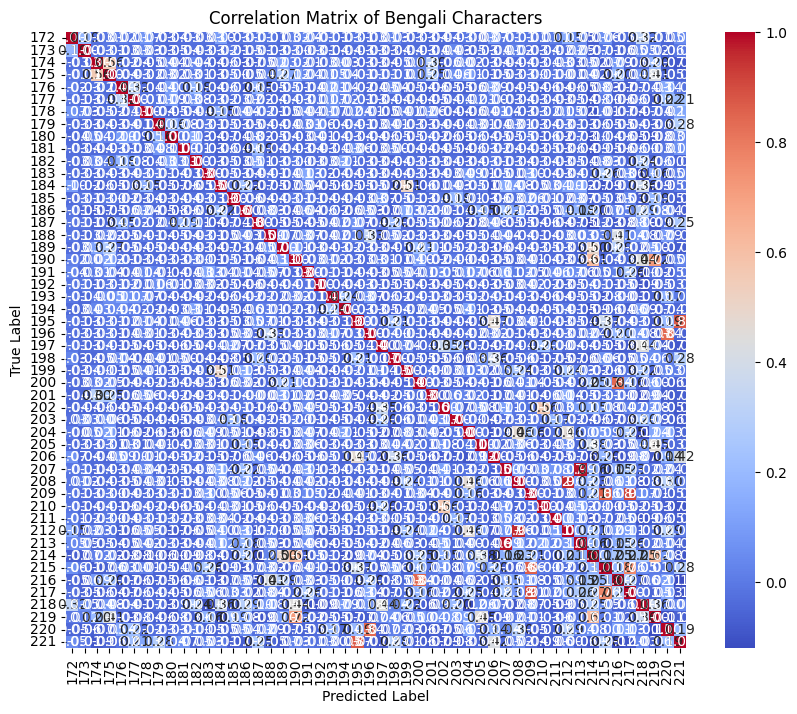

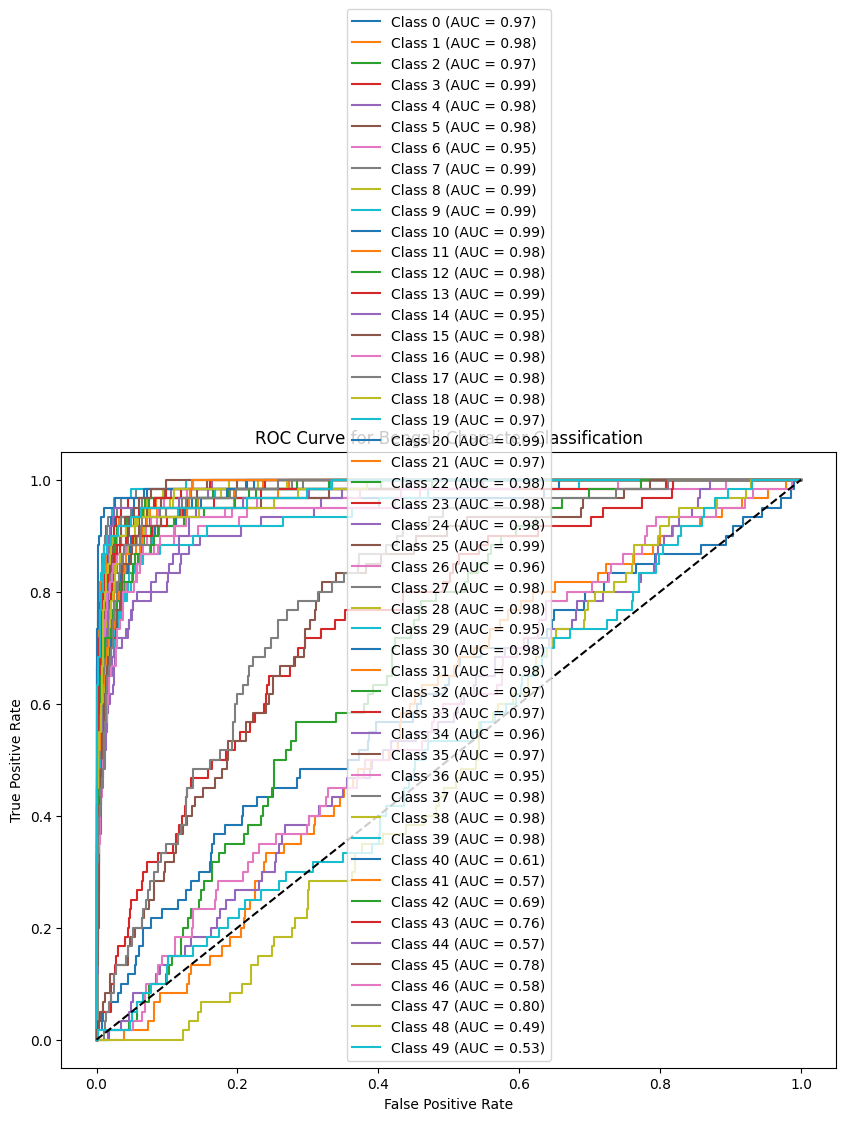

In [ ]:
%pip install scikit-learn

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Function to plot correlation matrix
def plot_correlation_matrix(y_true, y_pred, class_names):
    conf_matrix = confusion_matrix(y_true, y_pred)
    corr_matrix = np.corrcoef(conf_matrix)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=class_names, yticklabels=class_names)
    plt.title("Correlation Matrix of Bengali Characters")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

# Function to plot ROC curve
def plot_roc_curve(y_true, y_pred_probs, num_classes):
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    
    plt.figure(figsize=(10, 8))
    
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")
    
    plt.plot([0, 1], [0, 1], "k--")  # Random guessing line
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve for Bengali Character Classification")
    plt.legend()
    plt.show()

# Predict on test set
y_pred_probs = model.predict(test_images)
y_pred = np.argmax(y_pred_probs, axis=1)


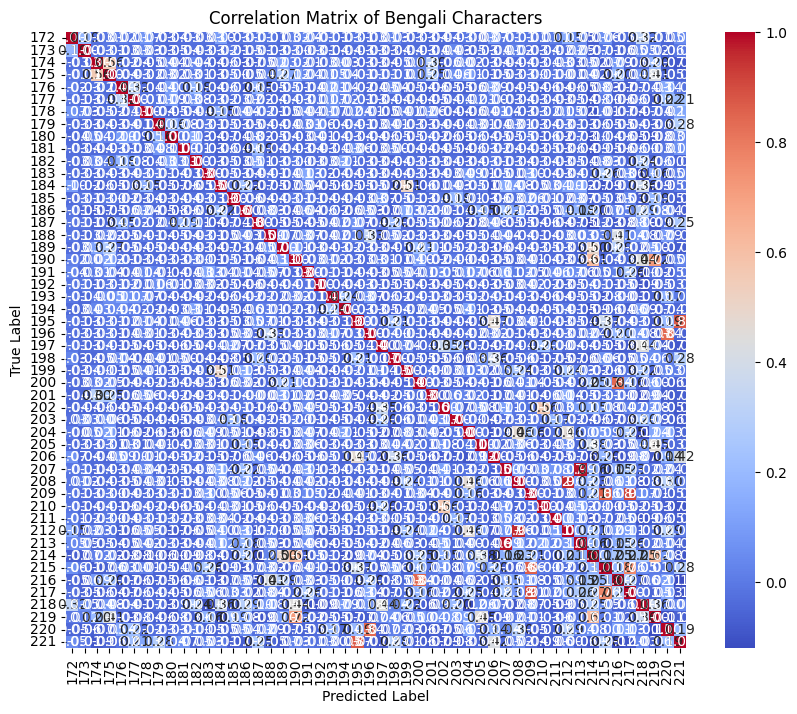

In [32]:
# Plot correlation matrix
plot_correlation_matrix(test_labels, y_pred, train_class_names)

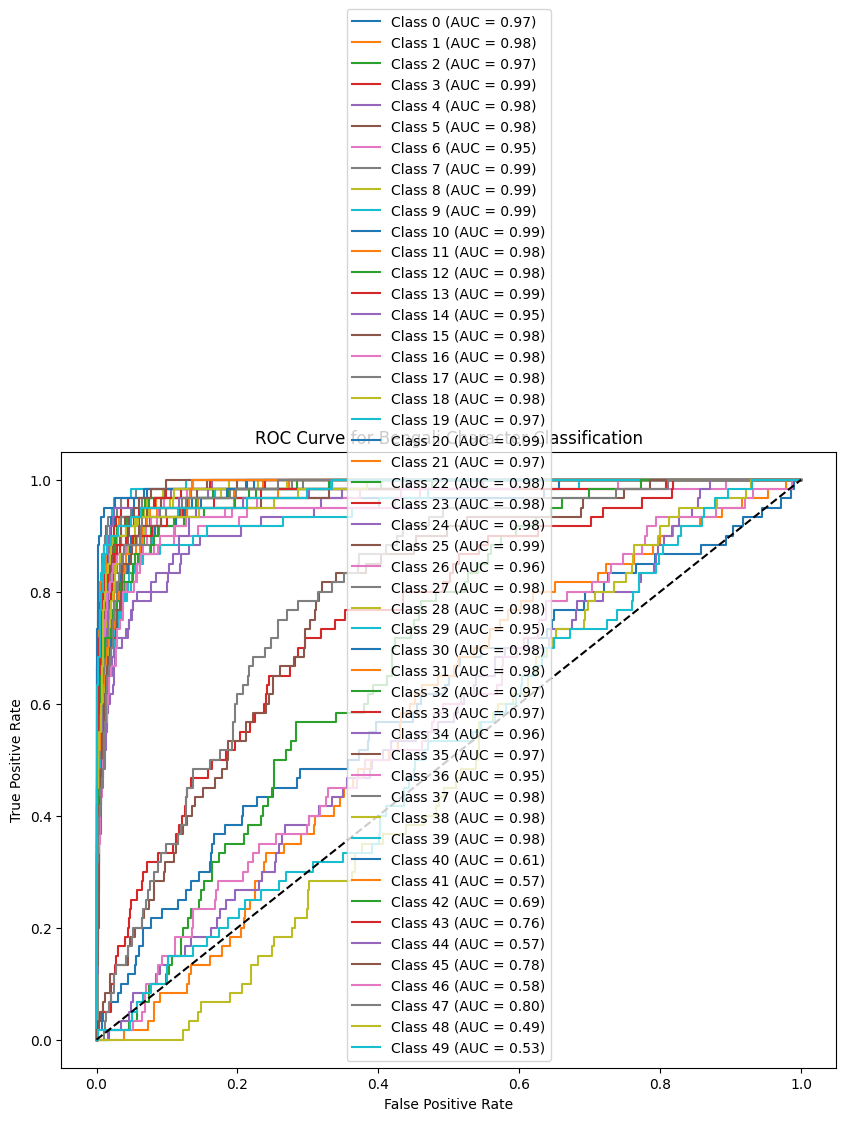

In [33]:
# Plot ROC curve
plot_roc_curve(test_labels, y_pred_probs, len(train_class_names))